In [1]:
import pickle

# Load the pickle file
with open('../network_data.pkl', 'rb') as f:
    data = pickle.load(f)

In [2]:
print(data)

{'nodes': [{'id': '134', 'group': 'Consensus (hard fork)', 'compliance_score': 82.35, 'created': '2016-07-27', 'author': ['Tom Zander <tomz@freedommail.ch>'], 'word_list': {'transaction': 32, 'we': 24, 'transactions': 16, 'format': 15, 'can': 15, 'input': 15, 'not': 14, 'tokens': 12, 'signatures': 12, 'future': 10, 'all': 9, 'new': 9, 'data': 9, 'have': 9, 'amount': 9, 'any': 9, 'version': 8, 'like': 8, 'fields': 8, 'they': 8, 'optional': 8, 'hash': 8, 'bitcoin': 7, 'use': 7, 'name': 7, 'spec': 7, 'without': 7, 'if': 7, 'bip': 6, 'flexible': 6, '4': 6, '0': 6, 'token': 6, 'which': 6, 'means': 6, 'integer': 6, 'order': 6, 'id': 6, 'spending': 6, 'bytearray': 6, 'used': 6, 'https': 5, 'github': 5, 'com': 5, 'following': 5, 'cmf': 5, 'based': 5, 'value': 5, 'after': 5, 'blob': 5, 'part': 5, 'tx': 5, 'signature': 5, 'v4': 5, 'txend': 5, 'implementation': 5, 'comments': 4, 'type': 4, 'next': 4, 'same': 4, 'time': 4, 'malleability': 4, 'message': 4, 'where': 4, 'because': 4, 'added': 4, 'upg

In [3]:
import networkx as nx
import matplotlib.pyplot as plt

In [4]:
def draw_static_network(data, link_type='references', color_by='group'):
    G = nx.DiGraph()

    # Add nodes with attributes
    for node in data['nodes']:
        G.add_node(
            node['id'],
            group=node.get('group'),
            compliance_score=node.get('compliance_score', 0)
        )

    # Add edges for the selected link type
    for link in data['links'].get(link_type, []):
        G.add_edge(link['source'], link['target'])

    # Compute layout (spring = force-directed)
    pos = nx.spring_layout(G, k=0.5, iterations=100, seed=42)

    # Color nodes
    if color_by == 'compliance_score':
        color_values = [
            G.nodes[n].get('compliance_score', 0) or 0
            for n in G.nodes
        ]
        cmap = plt.cm.Blues
    else:  # color_by group
        groups = list(set(nx.get_node_attributes(G, 'group').values()))
        group_map = {group: i for i, group in enumerate(groups)}
        color_values = [group_map.get(G.nodes[n].get('group'), 0) for n in G.nodes]
        cmap = plt.cm.tab10  # or plt.cm.Set3 for pastel

    # Draw
    plt.figure(figsize=(12, 8))
    nodes = nx.draw_networkx_nodes(
        G, pos, node_size=300, node_color=color_values, cmap=cmap, alpha=0.85
    )
    edges = nx.draw_networkx_edges(G, pos, alpha=0.3, arrows=True, arrowstyle='->')
    labels = nx.draw_networkx_labels(G, pos, font_size=8)

    plt.title(f"BIP Network - Link Type: {link_type} | Colored by: {color_by}")
    plt.axis('off')
    plt.colorbar(nodes)
    plt.tight_layout()
    plt.show()


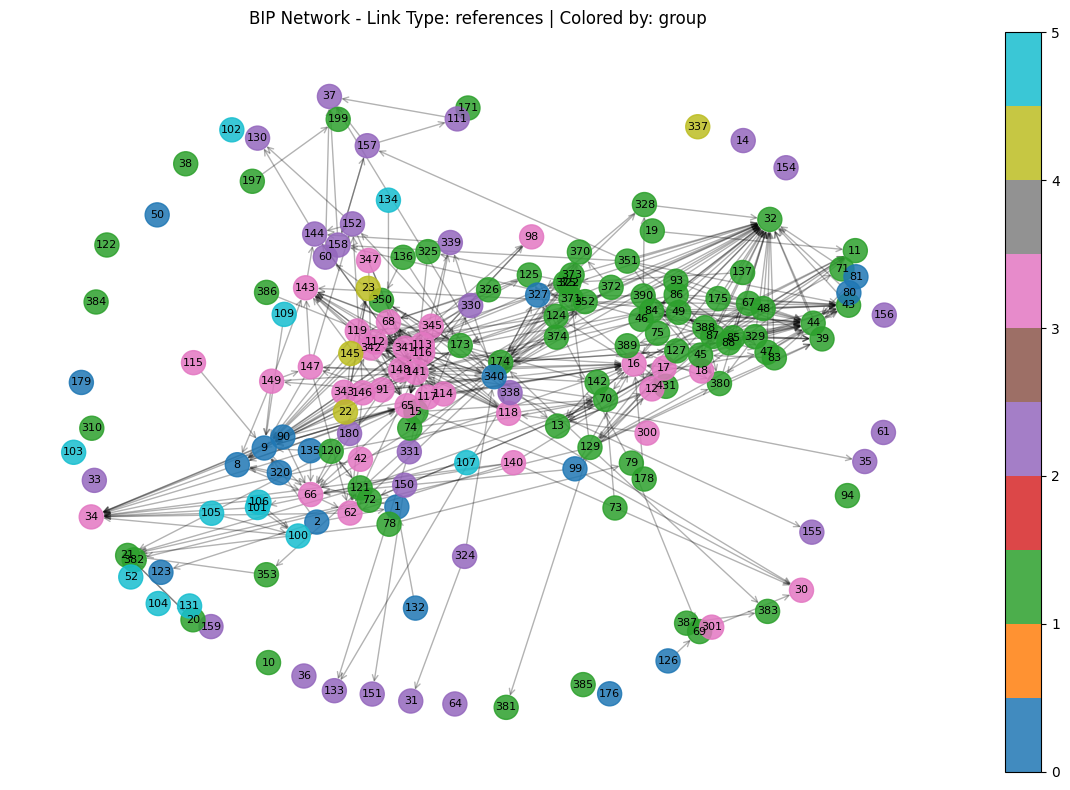

In [5]:
draw_static_network(data, link_type='references', color_by='group')

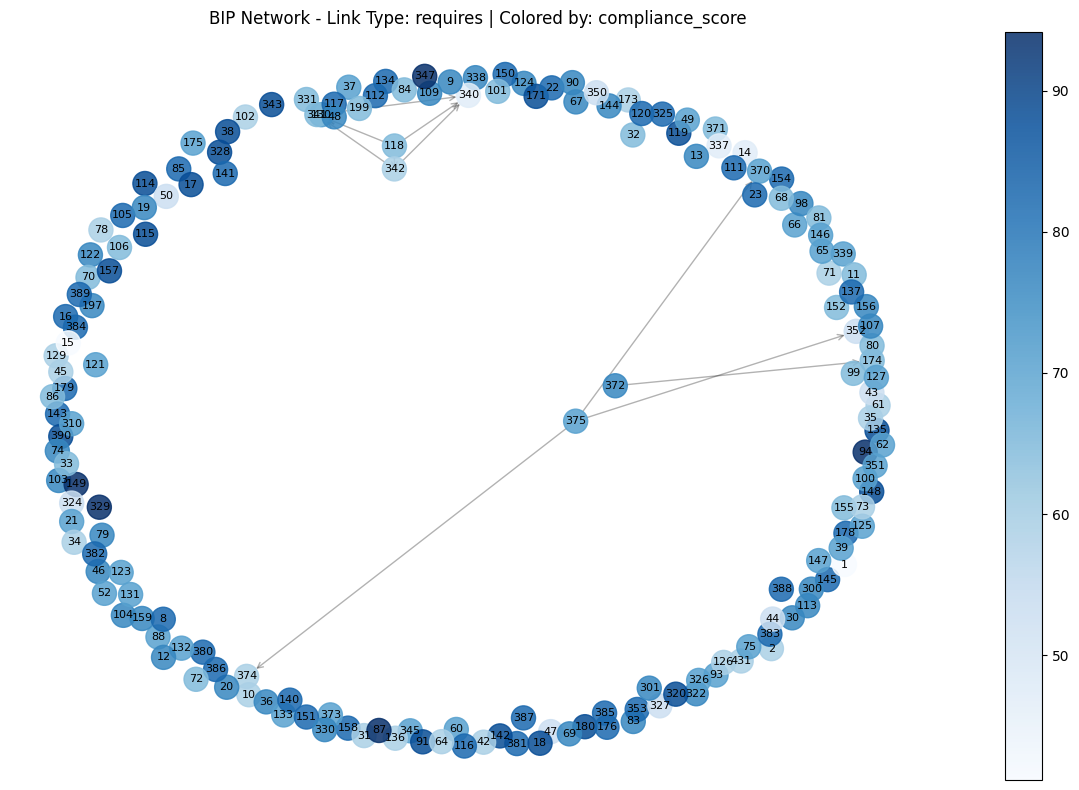

In [6]:
draw_static_network(data, link_type='requires', color_by='compliance_score')

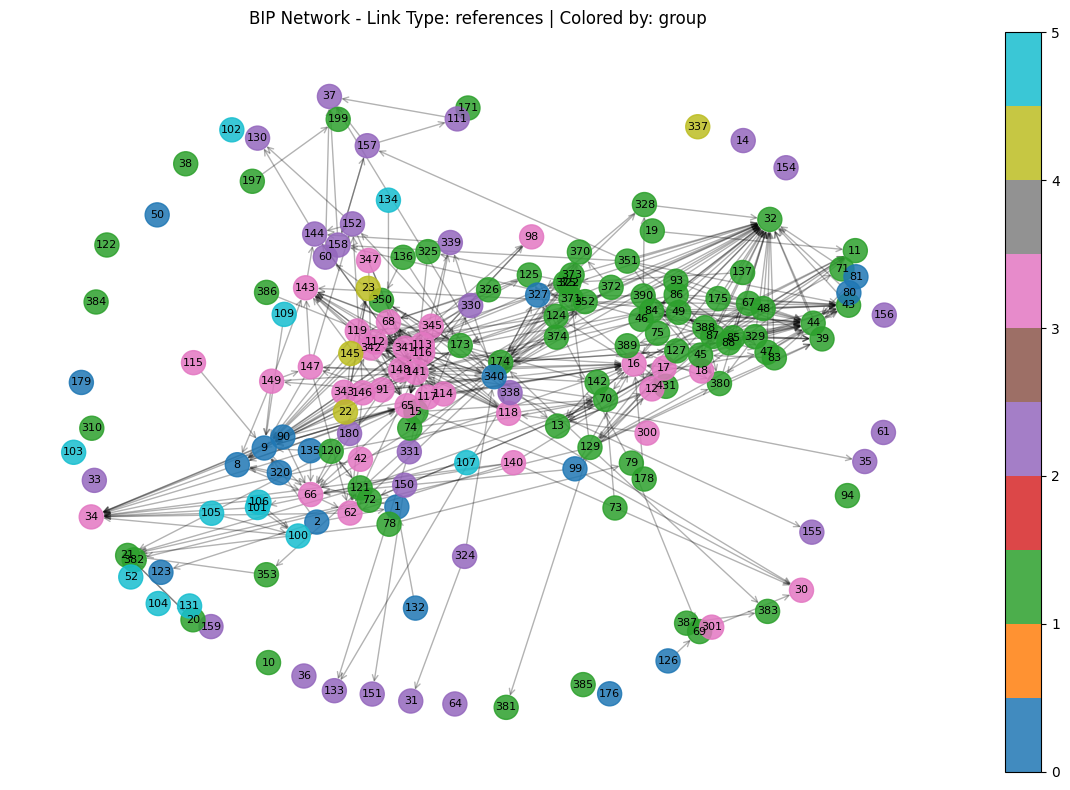

In [7]:
draw_static_network(data, link_type='references', color_by='group')

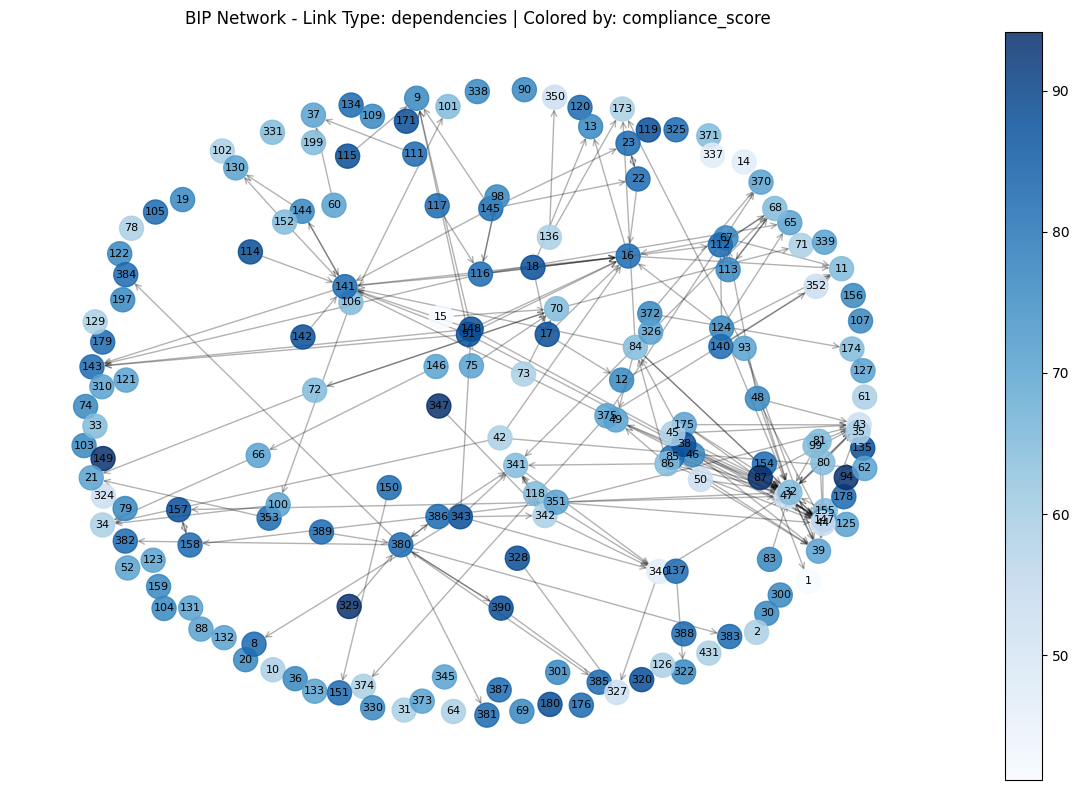

In [8]:
draw_static_network(data, link_type='dependencies', color_by='compliance_score')

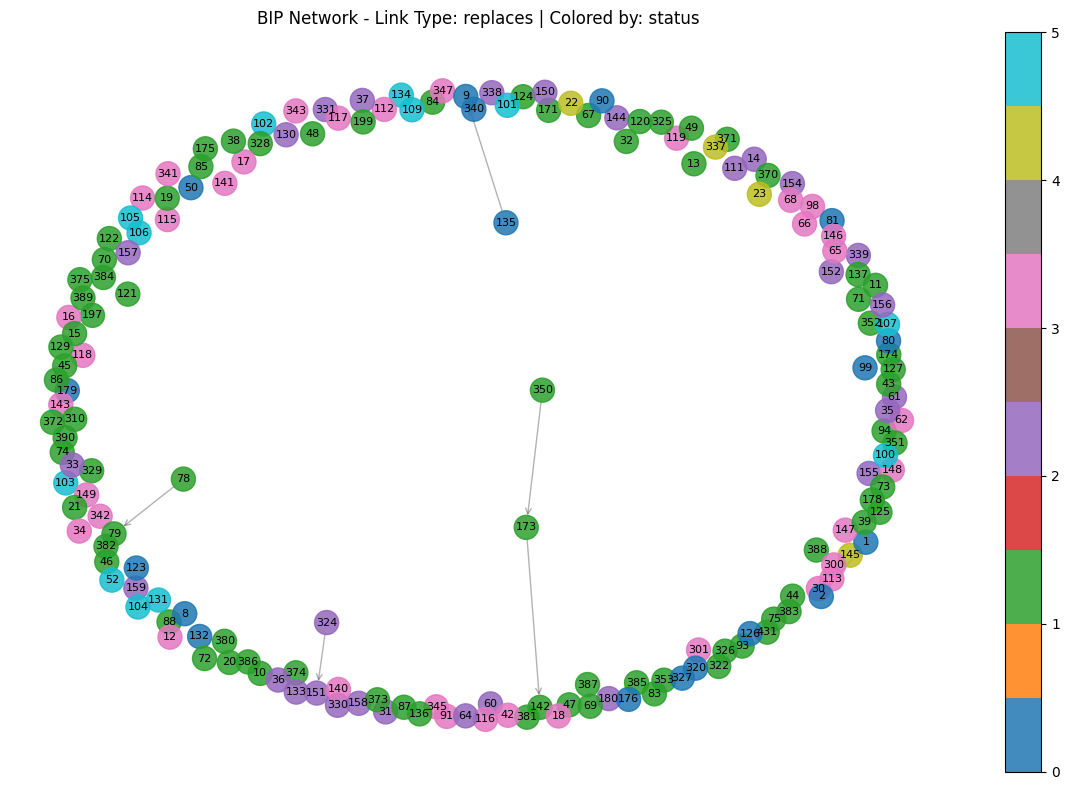

In [9]:
draw_static_network(data, link_type='replaces', color_by='status')